In [30]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from datasets import load_dataset

dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_review_All_Beauty", trust_remote_code=True)
data = dataset['full'].to_pandas()

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
# from sklearn.feature_extraction.text import TfidfVectorizer

metadata = pd.read_json("C:/Ironhack/W6/ReviewSense/datasets/meta_All_Beauty.jsonl", lines=True)


In [33]:
print(data.shape)
data.fillna("",inplace=True)
print(data.head())
print(data.columns)


(701528, 10)
   rating                                      title  \
0     5.0  Such a lovely scent but not overpowering.   
1     4.0     Works great but smells a little weird.   
2     5.0                                       Yes!   
3     1.0                          Synthetic feeling   
4     5.0                                         A+   

                                                text images        asin  \
0  This spray is really nice. It smells really go...     []  B00YQ6X8EO   
1  This product does what I need it to do, I just...     []  B081TJ8YS3   
2                          Smells good, feels great!     []  B07PNNCSP9   
3                                     Felt synthetic     []  B09JS339BZ   
4                                            Love it     []  B08BZ63GMJ   

  parent_asin                       user_id      timestamp  helpful_vote  \
0  B00YQ6X8EO  AGKHLEW2SOWHNMFQIJGBECAF7INQ  1588687728923             0   
1  B081TJ8YS3  AGKHLEW2SOWHNMFQIJGBECAF7INQ  15

In [13]:
print(metadata.shape)
metadata.fillna("",inplace=True)
print(metadata.head())
print(metadata.columns)


(112590, 14)
  main_category                                              title  \
0    All Beauty  Howard LC0008 Leather Conditioner, 8-Ounce (4-...   
1    All Beauty  Yes to Tomatoes Detoxifying Charcoal Cleanser ...   
2    All Beauty   Eye Patch Black Adult with Tie Band (6 Per Pack)   
3    All Beauty  Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...   
4    All Beauty  Precision Plunger Bars for Cartridge Grips – 9...   

   average_rating  rating_number  \
0             4.8             10   
1             4.5              3   
2             4.4             26   
3             3.1            102   
4             4.3              7   

                                            features  \
0                                                 []   
1                                                 []   
2                                                 []   
3                                                 []   
4  [Material: 304 Stainless Steel; Brass tip, Len...   

            

In [34]:
# the column names shows we can remove some columns that are not relevant to our proj

#PREPOC 1
data.drop(columns=['images', 'asin', 'parent_asin', 'user_id',
       'timestamp',], inplace=True)
# print(data.head())
print(data.columns)
print(data.iloc[0])

Index(['rating', 'title', 'text', 'helpful_vote', 'verified_purchase'], dtype='object')
rating                                                             5.0
title                        Such a lovely scent but not overpowering.
text                 This spray is really nice. It smells really go...
helpful_vote                                                         0
verified_purchase                                                 True
Name: 0, dtype: object


In [35]:
import seaborn as sns

#check for missing values, since we have only a few rows with missing values, we can drop them
#PREPOC 2

missing_counts = data.isna().sum()
print(missing_counts)
data = data.dropna() 
missing_counts = data.isna().sum()
print(missing_counts)

rating               0
title                0
text                 0
helpful_vote         0
verified_purchase    0
dtype: int64
rating               0
title                0
text                 0
helpful_vote         0
verified_purchase    0
dtype: int64


455
112135


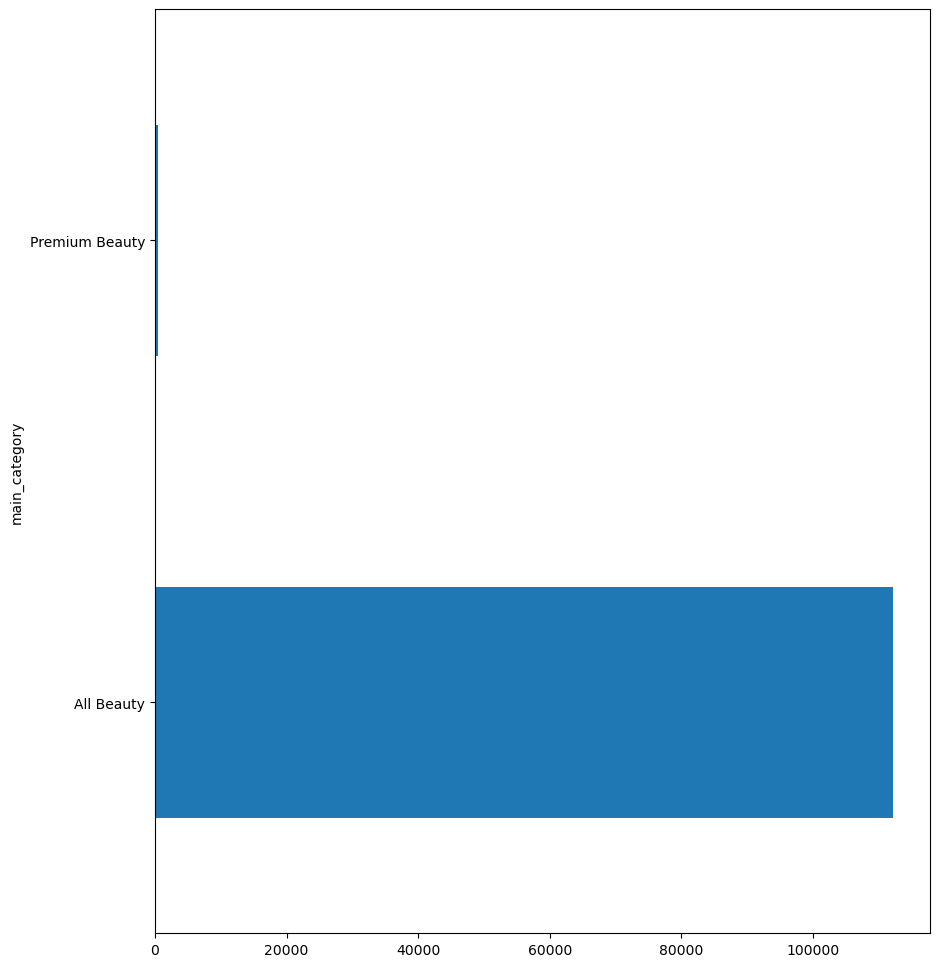

In [20]:
clean_categories = metadata['main_category'].str.split(',').str[-1].str.strip()
clean_categories.value_counts()[:40].plot(kind='barh', figsize=(10,12))
print((metadata['main_category'] == 'Premium Beauty').sum())
print((metadata['main_category'] == 'All Beauty').sum())

# clean_categories = metadata['categories'].str.split(',').str[-1].str.strip()
# clean_categories.value_counts()[:40].plot(kind='barh', figsize=(10,12))
# # print((metadata['main_category'] == 'Premium Beauty').sum())
# # print((metadata['main_category'] == 'All Beauty').sum())

In [ ]:
# Plotting the top 40 cleaned categories
main_category.value_counts()[:40].plot(kind='bar', figsize=(12, 6))

# Apply log scale to the Y-axis
plt.yscale('log')

plt.title('Category Distribution (Log Scale)')
plt.ylabel('Count (Log Scale)')
plt.show()


In [14]:
top5_pct = metadata['main_category'].value_counts(normalize=True)[:5].sum() * 100
top5_pct2 = metadata['categories'].value_counts(normalize=True)[:5].sum() * 100
print(f"The top 5 categories make up {top5_pct:.2f}% of the data.")
print(f"The top 5 categories make up {top5_pct2:.2f}% of the data.")


# since the top 5 categories make up 60% of the data we can conclude the categories are imabalanced

The top 5 categories make up 100.00% of the data.
The top 5 categories make up 100.00% of the data.


In [39]:
#now lets check the distribution of the ratings
# sns.countplot(x='reviews.rating', data=data, palette='viridis')
# plt.title('Ratings Distribution')

# the ratings are also imbalanced with most of the ratings being 5 stars. Needs to be addressed while modelling
# since we are trying do sentiment analysis of the reviews, we can create a new column called sentiment which will be positive for ratings 4 and 5, negative for 1 and 2, and neutral for 3.

ratings_map = {5:'pos',4:'pos',3:'neu',2:'neg',1:'neg'}
data['rating_sentiment'] = data['rating'].map(ratings_map)

# data.groupby('reviews.rating')['reviews.doRecommend'].mean().plot(kind='bar')
# data.groupby('rating_sentiment')['reviews.doRecommend'].mean().plot(kind='bar')
# print(data["rating_sentiment"].value_counts())

In [40]:
print((data['rating_sentiment'] == 'pos').sum())
print((data['rating_sentiment'] == 'neg').sum())
print((data['rating_sentiment'] == 'neu').sum())

500107
145114
56307


0.1620747853257461


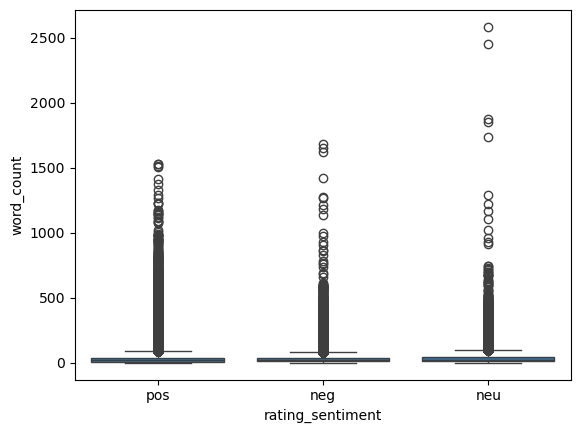

In [41]:
data['word_count'] = data['text'].str.split().str.len()
sns.boxplot(x='rating_sentiment', y='word_count', data=data)
print((data['word_count'] > 400).mean() * 100)

0.08602070773786938


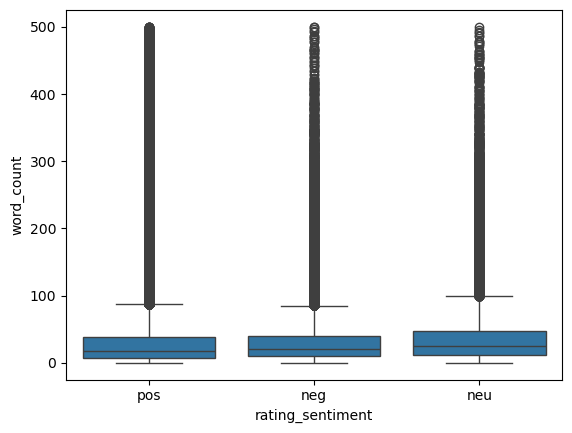

In [42]:
df_filtered = data[data['word_count'] <= 500]
# data['word_count'] = data['reviews.text'].str.split().str.len()
sns.boxplot(x='rating_sentiment', y='word_count', data=df_filtered)
print((df_filtered['word_count'] > 400).mean() * 100)

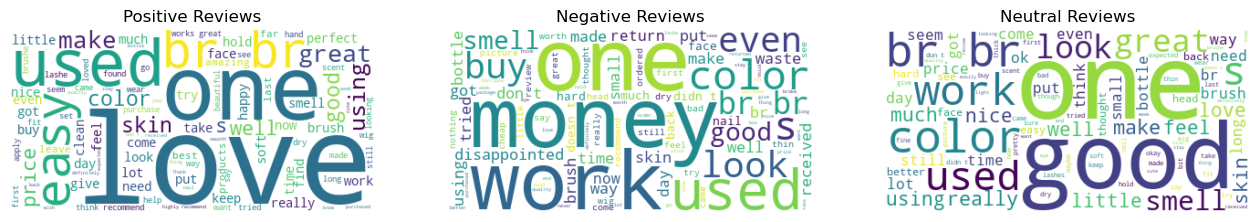

In [43]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt


STOPWORDS.update(["product", "item", "Amazon", "Kindle", "use", "app", "will", "tablet", "bought", "hair" ])
# 1. Create text blobs for each sentiment
pos_text = " ".join(data[data['rating_sentiment'] == 'pos']['text'])
neg_text = " ".join(data[data['rating_sentiment'] == 'neg']['text'])
neu_text = " ".join(data[data['rating_sentiment'] == 'neu']['text'])

# 2. Generate and plot
wc = WordCloud(stopwords=STOPWORDS, background_color='white', max_words=100)

plt.figure(figsize=(16, 8))

# Positive Cloud
plt.subplot(1, 3, 1)
plt.imshow(wc.generate(pos_text), interpolation='bilinear')
plt.title('Positive Reviews')
plt.axis('off')

# Negative Cloud
plt.subplot(1, 3, 2)
plt.imshow(wc.generate(neg_text), interpolation='bilinear')
plt.title('Negative Reviews')
plt.axis('off')

# Neutral Cloud
plt.subplot(1, 3, 3)
plt.imshow(wc.generate(neu_text), interpolation='bilinear')
plt.title('Neutral Reviews')
plt.axis('off')


plt.show()
